In [12]:
import pandas as pd
import numpy as np
orders = pd.read_csv('Dataset/orders.csv')
products = pd.read_csv('Dataset/products.csv')
order_items = pd.read_csv('Dataset/order_items.csv', dtype={'promo_id_2': str})
customers = pd.read_csv('Dataset/customers.csv')
returns = pd.read_csv('Dataset/returns.csv')

In [13]:
print(f"Số lượng đơn hàng: {orders.shape[0]}")
print(f"Số lượng khách hàng: {customers.shape[0]}")
print(f"Số lượng sản phẩm: {products.shape[0]}")

orders.head()

Số lượng đơn hàng: 646945
Số lượng khách hàng: 121930
Số lượng sản phẩm: 2412


,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign


In [14]:
import pandas as pd

orders = pd.read_csv('Dataset/orders.csv')

orders['order_date'] = pd.to_datetime(orders['order_date'], dayfirst=False)

unique_orders = orders[['customer_id', 'order_date']].drop_duplicates()

unique_orders = unique_orders.sort_values(by=['customer_id', 'order_date'])

customer_counts = unique_orders['customer_id'].value_counts()
multi_order_customers = customer_counts[customer_counts >= 2].index
filtered_orders = unique_orders[unique_orders['customer_id'].isin(multi_order_customers)].copy()

filtered_orders['gap'] = filtered_orders.groupby('customer_id')['order_date'].diff().dt.days

final_gap_series = filtered_orders['gap'].dropna()
ans_q1 = final_gap_series.median()

print(f"Số lượng khoảng cách tính được: {len(final_gap_series)}")
print(f"Giá trị Trung vị (Median): {ans_q1} ngày")

Số lượng khoảng cách tính được: 551620
Giá trị Trung vị (Median): 146.0 ngày


Q1

In [15]:
orders_cleaned = orders[orders['order_status'] == 'delivered'].copy()

unique_orders = orders_cleaned[['customer_id', 'order_date']].drop_duplicates()
unique_orders = unique_orders.sort_values(by=['customer_id', 'order_date'])

# Tính gap
unique_orders['gap'] = unique_orders.groupby('customer_id')['order_date'].diff().dt.days
final_gap_series = unique_orders['gap'].dropna()

print(f"Giá trị Trung vị sau khi lọc status: {final_gap_series.median()} ngày")

Giá trị Trung vị sau khi lọc status: 178.0 ngày


Q2

In [16]:
products = pd.read_csv('Dataset/products.csv')

products['gross_margin'] = (products['price'] - products['cogs']) / products['price']

segment_analysis = products.groupby('segment')['gross_margin'].mean().sort_values(ascending=False)

print("--- Tỷ suất lợi nhuận gộp trung bình theo phân khúc ---")
print(segment_analysis)

best_segment = segment_analysis.idxmax()
best_value = segment_analysis.max()

print(f"\n=> Phân khúc có tỷ suất lợi nhuận cao nhất là: {best_segment} ({best_value:.4f})")

--- Tỷ suất lợi nhuận gộp trung bình theo phân khúc ---
segment
Standard       0.313442
Premium        0.285377
All-weather    0.284176
Activewear     0.265600
Performance    0.263650
Balanced       0.258038
Trendy         0.240758
Everyday       0.236343
Name: gross_margin, dtype: float64

=> Phân khúc có tỷ suất lợi nhuận cao nhất là: Standard (0.3134)


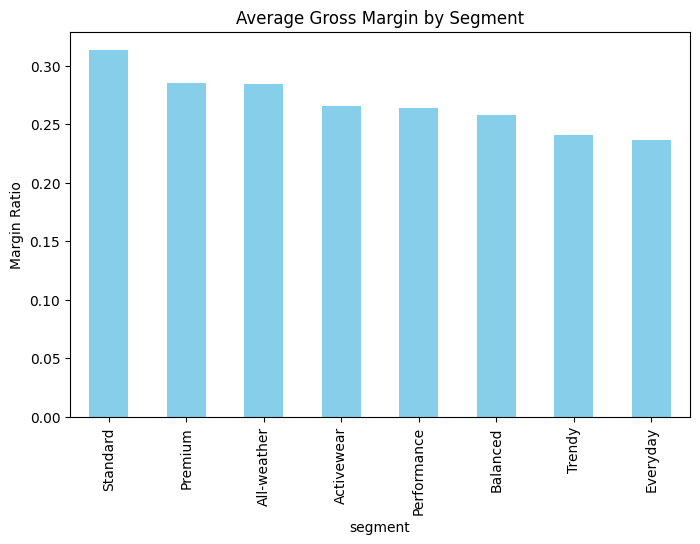

In [17]:
import matplotlib.pyplot as plt
segment_analysis.plot(kind='bar', color='skyblue', figsize=(8, 5))
plt.title('Average Gross Margin by Segment')
plt.ylabel('Margin Ratio')
plt.show()

Q3

In [18]:
returns = pd.read_csv('Dataset/returns.csv')
products = pd.read_csv('Dataset/products.csv')

merged_returns = pd.merge(returns, products, on='product_id', how='inner')

streetwear_returns = merged_returns[merged_returns['category'] == 'Streetwear']

reason_counts = streetwear_returns['return_reason'].value_counts()

print("--- Thống kê lý do trả hàng cho danh mục Streetwear ---")
print(reason_counts)

top_reason = reason_counts.idxmax()
print(f"\n=> Lý do trả hàng xuất hiện nhiều nhất là: {top_reason}")

--- Thống kê lý do trả hàng cho danh mục Streetwear ---
return_reason
wrong_size          7626
defective           4330
not_as_described    3854
changed_mind        3830
late_delivery       2159
Name: count, dtype: int64

=> Lý do trả hàng xuất hiện nhiều nhất là: wrong_size


Q4

In [19]:
web_traffic = pd.read_csv('Dataset/web_traffic.csv')

source_performance = web_traffic.groupby('traffic_source')['bounce_rate'].mean().sort_values()

print("--- Tỷ lệ thoát trung bình theo nguồn truy cập ---")
print(source_performance)

best_source = source_performance.idxmin()
min_bounce_rate = source_performance.min()

print(f"\n=> Nguồn có tỷ lệ thoát thấp nhất là: {best_source} ({min_bounce_rate:.4f})")

--- Tỷ lệ thoát trung bình theo nguồn truy cập ---
traffic_source
email_campaign    0.004458
social_media      0.004476
paid_search       0.004478
referral          0.004499
organic_search    0.004504
direct            0.004511
Name: bounce_rate, dtype: float64

=> Nguồn có tỷ lệ thoát thấp nhất là: email_campaign (0.0045)


Q5

In [20]:
order_items = pd.read_csv('Dataset/order_items.csv', low_memory=False)

total_rows = len(order_items)

promo_count = order_items['promo_id'].notna().sum()

percentage = (promo_count / total_rows) * 100

print(f"Tổng số dòng: {total_rows}")
print(f"Số dòng có khuyến mãi: {promo_count}")
print(f"Tỷ lệ phần trăm: {percentage:.2f}%")

Tổng số dòng: 714669
Số dòng có khuyến mãi: 276316
Tỷ lệ phần trăm: 38.66%


Q6

In [21]:
import pandas as pd

customers = pd.read_csv('Dataset/customers.csv')
orders = pd.read_csv('Dataset/orders.csv')

customers_filtered = customers[customers['age_group'].notna()]

customers_per_age = customers_filtered.groupby('age_group')['customer_id'].nunique()

# Merge bảng khách hàng đã lọc với bảng orders để lấy thông tin đơn hàng
merged_data = pd.merge(customers_filtered, orders, on='customer_id', how='inner')

orders_per_age = merged_data.groupby('age_group')['order_id'].nunique()

# Tính số đơn hàng trung bình trên mỗi khách hàng
avg_orders_per_customer = (orders_per_age / customers_per_age).sort_values(ascending=False)

print("--- Số đơn hàng trung bình trên mỗi khách hàng theo nhóm tuổi ---")
print(avg_orders_per_customer)

best_age_group = avg_orders_per_customer.idxmax()
print(f"\n=> Nhóm tuổi có số đơn hàng trung bình cao nhất là: {best_age_group}")

--- Số đơn hàng trung bình trên mỗi khách hàng theo nhóm tuổi ---
age_group
55+      5.406851
45-54    5.357241
35-44    5.337343
25-34    5.245226
18-24    5.226656
dtype: float64

=> Nhóm tuổi có số đơn hàng trung bình cao nhất là: 55+


Q7

In [22]:
import pandas as pd

order_items = pd.read_csv('Dataset/order_items.csv', low_memory=False)
orders = pd.read_csv('Dataset/orders.csv')
customers = pd.read_csv('Dataset/customers.csv')
geo = pd.read_csv('Dataset/geography.csv')
returns = pd.read_csv('Dataset/returns.csv')
print("--- CÁC TRẠNG THÁI ĐƠN HÀNG HIỆN CÓ ---")
print(orders['order_status'].unique())

--- CÁC TRẠNG THÁI ĐƠN HÀNG HIỆN CÓ ---
<ArrowStringArray>
['delivered', 'returned', 'shipped', 'cancelled', 'paid', 'created']
Length: 6, dtype: str


In [23]:
import pandas as pd

order_items = pd.read_csv('Dataset/order_items.csv', low_memory=False)
orders = pd.read_csv('Dataset/orders.csv')
customers = pd.read_csv('Dataset/customers.csv')
geo = pd.read_csv('Dataset/geography.csv')
returns = pd.read_csv('Dataset/returns.csv')

# Làm sạch đơn hàng (Loại bỏ đơn hủy và đơn trả hàng)
orders_ok = orders[orders['order_status'] != 'cancelled'].copy()
returned_orders = returns['order_id'].unique()
orders_final = orders_ok[~orders_ok['order_id'].isin(returned_orders)]


qty_col = 'quantity' if 'quantity' in order_items.columns else 'qty'
order_items['line_revenue'] = order_items[qty_col] * order_items['unit_price']

df_merged = pd.merge(order_items[['order_id', 'line_revenue']],
                     orders_final[['order_id', 'customer_id']],
                     on='order_id', how='inner')

df_merged = pd.merge(df_merged, customers[['customer_id', 'zip']], on='customer_id', how='inner')

df_merged = pd.merge(df_merged, geo[['zip', 'region']], on='zip', how='inner')

region_revenue = df_merged.groupby('region')['line_revenue'].sum().sort_values(ascending=False)

print("--- Kết quả Doanh thu thuần theo Vùng (Sử dụng unit_price) ---")
print(region_revenue)
print(f"\n=> Đáp án Q7 là vùng: {region_revenue.idxmax()}")

--- Kết quả Doanh thu thuần theo Vùng (Sử dụng unit_price) ---
region
East       6.516301e+09
Central    4.208868e+09
West       3.284103e+09
Name: line_revenue, dtype: float64

=> Đáp án Q7 là vùng: East


In [24]:
import pandas as pd

order_items = pd.read_csv('Dataset/order_items.csv', low_memory=False)
orders = pd.read_csv('Dataset/orders.csv')
customers = pd.read_csv('Dataset/customers.csv')
geo = pd.read_csv('Dataset/geography.csv')
returns = pd.read_csv('Dataset/returns.csv')


# Chỉ lấy các đơn đã thanh toán hoặc đang/đã giao
revenue_status = ['delivered', 'shipped', 'paid']
orders_ok = orders[orders['order_status'].isin(revenue_status)].copy()

# Loại bỏ thêm các đơn nằm trong danh sách trả hàng (returns)
returned_ids = returns['order_id'].unique()
orders_final = orders_ok[~orders_ok['order_id'].isin(returned_ids)]

qty_col = 'quantity' if 'quantity' in order_items.columns else 'qty'
order_items['line_revenue'] = order_items[qty_col] * order_items['unit_price']


df_merged = pd.merge(order_items[['order_id', 'line_revenue']],
                     orders_final[['order_id', 'customer_id']],
                     on='order_id')

df_merged = pd.merge(df_merged, customers[['customer_id', 'zip']], on='customer_id')

df_merged = pd.merge(df_merged, geo[['zip', 'region']], on='zip')

region_revenue = df_merged.groupby('region')['line_revenue'].sum().sort_values(ascending=False)

print("--- Kết quả Doanh thu thuần theo Vùng ---")
print(region_revenue)
print(f"\n=> Đáp án Q7 là vùng: {region_revenue.idxmax()}")

--- Kết quả Doanh thu thuần theo Vùng ---
region
East       6.425066e+09
Central    4.151299e+09
West       3.240026e+09
Name: line_revenue, dtype: float64

=> Đáp án Q7 là vùng: East


Q8

In [25]:
import pandas as pd

orders = pd.read_csv('Dataset/orders.csv')

cancelled_orders = orders[orders['order_status'] == 'cancelled']

payment_counts = cancelled_orders['payment_method'].value_counts()

print("--- Thống kê phương thức thanh toán của đơn hàng bị hủy ---")
print(payment_counts)

top_payment = payment_counts.idxmax()
print(f"\n=> Phương thức thanh toán bị hủy nhiều nhất là: {top_payment}")

--- Thống kê phương thức thanh toán của đơn hàng bị hủy ---
payment_method
credit_card      28452
cod              15468
paypal            7817
apple_pay         5190
bank_transfer     2535
Name: count, dtype: int64

=> Phương thức thanh toán bị hủy nhiều nhất là: credit_card


Q9

In [26]:
import pandas as pd

order_items = pd.read_csv('Dataset/order_items.csv', low_memory=False)
products = pd.read_csv('Dataset/products.csv')
returns = pd.read_csv('Dataset/returns.csv')

items_with_size = pd.merge(
    order_items[['order_id', 'product_id']],
    products[['product_id', 'size']],
    on='product_id',
    how='inner'
)

total_sold_by_size = items_with_size.groupby('size').size()

returned_items = pd.merge(
    items_with_size,
    returns[['order_id', 'product_id']],
    on=['order_id', 'product_id'],
    how='inner'
)

total_returned_by_size = returned_items.groupby('size').size()

target_sizes = ['S', 'M', 'L', 'XL']

return_rate_by_size = (total_returned_by_size / total_sold_by_size).reindex(target_sizes).fillna(0)

print("--- Tỷ lệ trả hàng theo kích thước (S, M, L, XL) ---")
print(return_rate_by_size.sort_values(ascending=False))

print(f"\n=> Đáp án Q9 (Kích thước có tỷ lệ trả cao nhất): {return_rate_by_size.idxmax()}")

--- Tỷ lệ trả hàng theo kích thước (S, M, L, XL) ---
size
S     0.056515
L     0.056250
M     0.055683
XL    0.055200
dtype: float64

=> Đáp án Q9 (Kích thước có tỷ lệ trả cao nhất): S


Q10

In [27]:
import pandas as pd

payments = pd.read_csv('Dataset/payments.csv')

installment_analysis = payments.groupby('installments')['payment_value'].mean().sort_values(ascending=False)

print("--- Giá trị thanh toán trung bình theo số kỳ trả góp ---")
print(installment_analysis)

print("\n--- Đối chiếu đáp án ---")
for i in [1, 3, 6, 12]:
    if i in installment_analysis.index:
        print(f"{i} kỳ: {installment_analysis[i]:,.2f} VND")

top_plan = installment_analysis.idxmax()
print(f"\n=> Kế hoạch trả góp có giá trị trung bình cao nhất là: {top_plan} kỳ")

--- Giá trị thanh toán trung bình theo số kỳ trả góp ---
installments
6     24446.654403
3     24399.635486
12    24245.772694
1     24113.274166
2       708.473729
Name: payment_value, dtype: float64

--- Đối chiếu đáp án ---
1 kỳ: 24,113.27 VND
3 kỳ: 24,399.64 VND
6 kỳ: 24,446.65 VND
12 kỳ: 24,245.77 VND

=> Kế hoạch trả góp có giá trị trung bình cao nhất là: 6 kỳ
